Importing all libraries

In [8]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Literal

Defining all the states

In [2]:
class QuadraticState(TypedDict):

    a: int
    b: int
    c: int

    equation: str
    discriminant: float
    result: str

Defining all the nodes

In [3]:
def quadratic_equation(state: QuadraticState):

    equation = f"{state['a']}x^2 + {state['b']}x + {state['c']} = 0"
    return {"equation": equation}

In [4]:
def calculate_discriminant(state: QuadraticState):

    a = state['a']
    b = state['b']
    c = state['c']
    discriminant = b**2 - 4*a*c
    return {"discriminant": discriminant}

In [5]:
def real_roots(state: QuadraticState):

    a = state['a']
    b = state['b']
    discriminant = state['discriminant']
    root1 = (-b + discriminant**0.5) / (2*a)
    root2 = (-b - discriminant**0.5) / (2*a)
    result = f"Real roots: {root1} and {root2}"
    return {"result": result}

In [6]:
def repeated_root(state: QuadraticState):

    a = state['a']
    b = state['b']
    root = -b / (2*a)
    result = f"Repeated root: {root}"
    return {"result": result}

In [7]:
def no_real_roots(state: QuadraticState):

    return {"result": "No real roots"}

**check_discriminant()** - is a python function(in below cell) that decides which node to be executed based on the condition(here the condition depends on the value of discriminant).

In [9]:
def check_discriminant(state: QuadraticState) -> Literal["real_roots", "repeated_root", "no_real_roots"]:

    discriminant = state['discriminant']
    if discriminant > 0:
        return "real_roots"
    elif discriminant == 0:
        return "repeated_root"
    else:
        return "no_real_roots"

Graph Creation

In [10]:
graph = StateGraph(QuadraticState)

Nodes and Edges Addition

Note:
```python
graph.add_conditional_edges("calculate_discriminant", check_discriminant)
```
Here the first field takes the node name after which condition is applied and the second field is the actual condition function that determied further which preceeding node will be executed based on the condition.

In [11]:
graph.add_node("quadratic_equation", quadratic_equation)
graph.add_node("calculate_discriminant", calculate_discriminant)
graph.add_node("real_roots", real_roots)
graph.add_node("repeated_root", repeated_root)
graph.add_node("no_real_roots", no_real_roots)



graph.add_edge(START, "quadratic_equation")
graph.add_edge("quadratic_equation", "calculate_discriminant")
graph.add_conditional_edges("calculate_discriminant", check_discriminant)
graph.add_edge("real_roots", END)
graph.add_edge("repeated_root", END)
graph.add_edge("no_real_roots", END)

In [12]:
workflow = graph.compile()

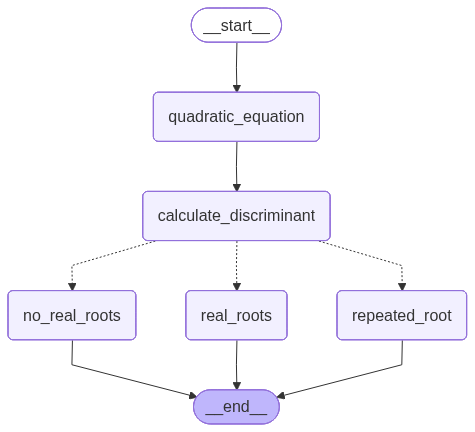

In [13]:
workflow

Graph Execution

In [14]:
initial_state = {
    "a": 1, "b": -3, "c": 2
    }
workflow.invoke(initial_state)

{'a': 1,
 'b': -3,
 'c': 2,
 'equation': '1x^2 + -3x + 2 = 0',
 'discriminant': 1,
 'result': 'Real roots: 2.0 and 1.0'}

In [16]:
initial_state = {
    "a": 4, "b": -4, "c": 4
    }
workflow.invoke(initial_state)

{'a': 4,
 'b': -4,
 'c': 4,
 'equation': '4x^2 + -4x + 4 = 0',
 'discriminant': -48,
 'result': 'No real roots'}

In [17]:
initial_state = {
    "a": 2, "b": 4, "c": 2
    }
workflow.invoke(initial_state)

{'a': 2,
 'b': 4,
 'c': 2,
 'equation': '2x^2 + 4x + 2 = 0',
 'discriminant': 0,
 'result': 'Repeated root: -1.0'}